# Lecture 10a: Quasi-Toeplitz structure and determinacy

This is the first of two notebooks for the lecture 10 slide deck. It focuses on the quasi-Toeplitz structure and its applications for determinacy, using the winding number test.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import linalg

import sequence_jacobian as sj
import sim_steady_state_fast as sim
from calibration import make_calibration
from winding_number import winding_number

# 1. Motivating example: Jacobians for Calvo pricing

In [2]:
beta = 0.98
theta = 0.75

In [3]:
T = 500
forward = (1-beta*theta)*(beta*theta)**np.arange(T)
Forward = np.triu(linalg.toeplitz(forward))

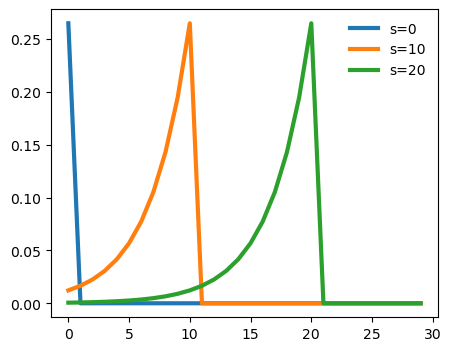

In [4]:
plt.figure(figsize=(5, 4))
plt.plot(Forward[:30, [0, 10, 20]], linewidth=3)
plt.legend(['s=0', 's=10', 's=20'], frameon=False)
plt.savefig('figures/lecture10a_fig1.pdf', transparent=True)

In [5]:
backward = (1-theta)*theta**np.arange(T)
Backward = np.tril(linalg.toeplitz(backward))

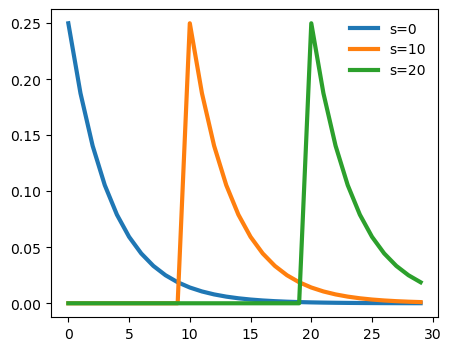

In [6]:
plt.figure(figsize=(5, 4))
plt.plot(Backward[:30, [0, 10, 20]], linewidth=3)
plt.legend(['s=0', 's=10', 's=20'], frameon=False)
plt.savefig('figures/lecture10a_fig2.pdf', transparent=True)

In [7]:
Psi = Backward @ Forward

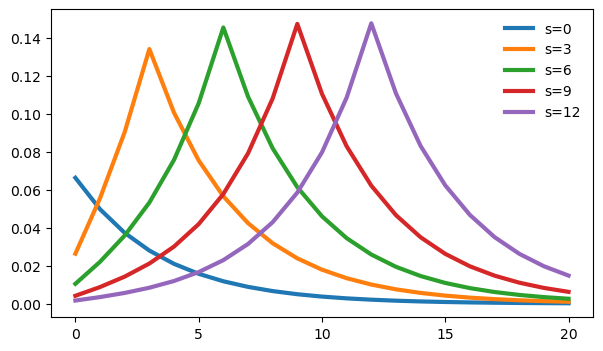

In [8]:
plt.figure(figsize=(7, 4))
plt.plot(Psi[:21, [0, 3, 6, 9, 12]], linewidth=3)
plt.legend(['s=0', 's=3', 's=6', 's=9', 's=12'], frameon=False)
plt.xticks([0, 5, 10, 15, 20])
plt.savefig('figures/lecture10a_fig3.pdf', transparent=True)

# 2. Heterogeneous-agent example: basic
Use the workshop's shared low-asset HANK calibration, with assets equal to 100% of annual GDP.

In [9]:
calib, e = make_calibration(lowA=True)

def income(e, Z):
    y = Z * e
    return y

hh = sj.hetblocks.hh_sim.hh.add_hetinputs([income])
calib_hh = {**calib, 'e': e, 'Z': 0.7}
ss_hh = hh.steady_state(calib_hh)
print(f"Steady state: r={ss_hh['r']:.4f}, C={ss_hh['C']:.4f}, A={ss_hh['A']:.4f}")

Steady state: r=0.0050, C=0.7200, A=4.0000


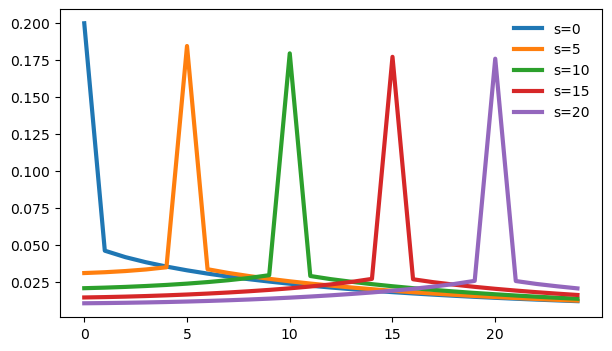

In [10]:
M = hh.jacobian(ss_hh, inputs=['Z'], outputs=['C'], T=500)['C', 'Z']
plt.figure(figsize=(7, 4))
plt.plot(M[:25, [0, 5, 10, 15, 20]], linewidth=3)
plt.legend(['s=0', 's=5', 's=10', 's=15', 's=20'], frameon=False)
plt.xticks([0, 5, 10, 15, 20])
plt.savefig('figures/lecture10a_fig4.pdf', transparent=True)

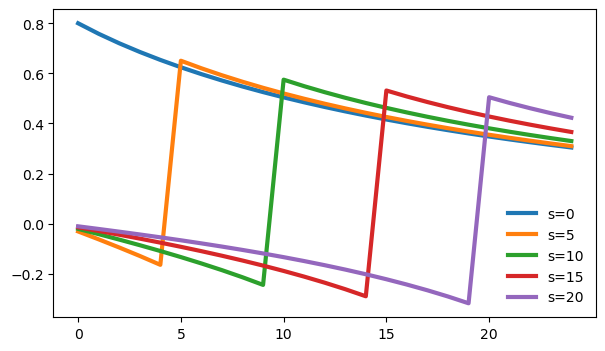

In [11]:
A = hh.jacobian(ss_hh, inputs=['Z'], outputs=['A'], T=500)['A', 'Z']
plt.figure(figsize=(7, 4))
plt.plot(A[:25, [0, 5, 10, 15, 20]], linewidth=3)
plt.legend(['s=0', 's=5', 's=10', 's=15', 's=20'], frameon=False)
plt.xticks([0, 5, 10, 15, 20])
plt.savefig('figures/lecture10a_fig5.pdf', transparent=True)

# 3. Heterogeneous-agent example: varying countercyclical risk parameter

Quickly modify model to allow for cyclicality of income risk / inequality, given by $\zeta$, like we saw in Adrien's second lecture:

In [12]:
def income_cyclical(Y, T, e_grid, e_pdf, zeta):
    e_scaled = e_grid ** (1 + zeta * np.log(Y))
    y = (Y - T) * e_scaled / np.vdot(e_scaled, e_pdf)
    return y

hh_cyc = sj.hetblocks.hh_sim.hh.add_hetinputs([income_cyclical])

Steady state with the shared low-asset calibration, assuming acyclical risk $\zeta=0$ to start:

In [13]:
e_pdf = sim.stationary_markov(calib['Pi'])
calib_cyc = {**calib, 'Y': 1, 'T': 0.3, 'e_grid': e, 'e_pdf': e_pdf, 'zeta': 0}
ss_cyc = hh_cyc.steady_state(calib_cyc)
print(f"Steady state: r={ss_cyc['r']:.4f}, C={ss_cyc['C']:.4f}, A={ss_cyc['A']:.4f}")

Steady state: r=0.0050, C=0.7200, A=4.0000


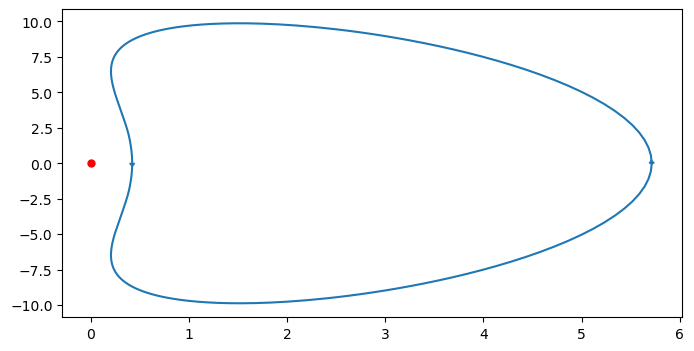

In [14]:
T = 1000
A = hh_cyc.jacobian(ss_cyc, inputs=['Y'], outputs=['A'], T=T)['A', 'Y']

# take final column and then final (reversed) row to get best estimate of Toeplitz
a = np.concatenate((A[:, -1], A[-1, :-1][::-1]))

# what is winding number in our default case?
plt.figure(figsize=(8, 4))
winding_number(a, plot=True)
plt.savefig('figures/lecture10a_fig6.pdf', transparent=True)

Now let's go to countercyclical case:

In [15]:
ss_alt = ss_cyc.copy()
ss_alt['zeta'] = -0.7
A_alt = hh_cyc.jacobian(ss_alt, inputs=['Y'], outputs=['A'], T=T)['A', 'Y']
a_alt = np.concatenate((A_alt[:, -1], A_alt[-1, :-1][::-1]))

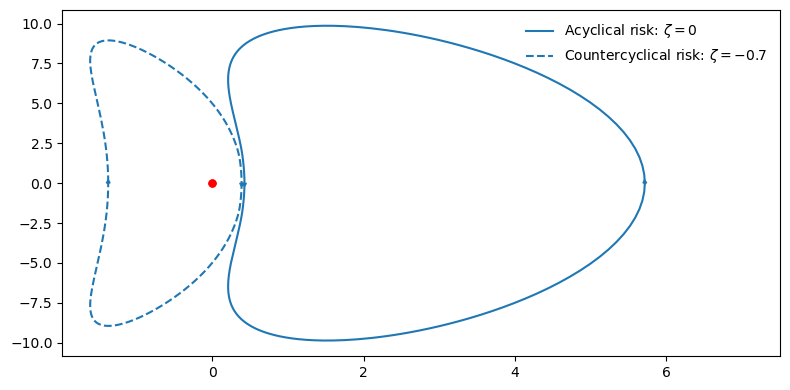

In [16]:
plt.figure(figsize=(8, 4))
(winding_number(a, plot=True, label=r'Acyclical risk: $\zeta=0$'),
winding_number(a_alt, plot=True, linestyle='--', label=rf'Countercyclical risk: $\zeta={ss_alt['zeta']:.1f}$'))
plt.xlim(None, 7.5)
plt.legend(frameon=False, loc='upper right')
plt.tight_layout()
plt.savefig('figures/lecture10a_fig7.pdf', transparent=True)

What does the multiplicity look like in the indeterminate case? Can use the singular value decomposition to find the vector that is nearly in the null-space of `A_alt`, which corresponds to a self-fulfilling fluctuation in output:

In [17]:
U, s, Vh = np.linalg.svd(A_alt)
s[-5:]

array([0.38656279, 0.38655947, 0.3865571 , 0.38655568, 0.11856502])

0.04126671799055838


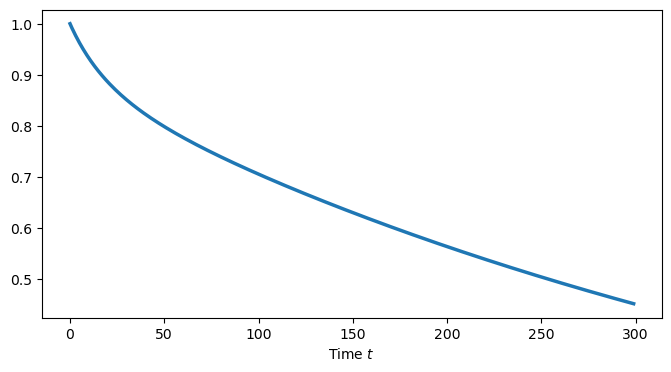

In [18]:
mult = Vh[-1, :300]
mult /= mult[0] # normalize so that output starts at +1
print(np.max(np.abs((A_alt[:300, :300] @ mult))[:150])) # test close to zero
plt.figure(figsize=(8, 4))
plt.plot(mult, linewidth=2.5)
plt.xlabel('Time $t$')
#plt.title('Self-fulfilling boom in output')
plt.savefig('figures/lecture10a_fig8.pdf', transparent=True)

Now let's iterate over various levels of $\zeta$ and plot the winding number in each case, to see when the model is determinate or not:

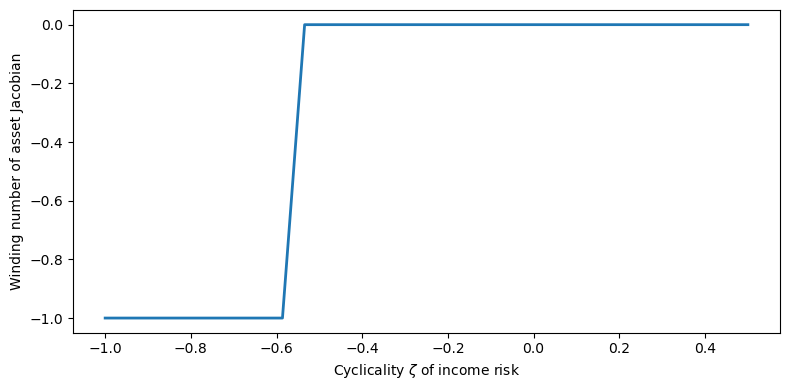

In [27]:
zetas = np.linspace(-1, 0.5, 30)
wn = np.empty_like(zetas)
for i, zeta in enumerate(zetas):
    ss_alt['zeta'] = zeta
    A_alt = hh_cyc.jacobian(ss_alt, inputs=['Y'], outputs=['A'], T=T)['A', 'Y']
    a_alt = np.concatenate((A_alt[:, -1], A_alt[-1, :-1][::-1]))
    wn[i] = winding_number(a_alt)
plt.figure(figsize=(8, 4))
plt.plot(zetas, wn, lw=2)
plt.xlabel(r'Cyclicality $\zeta$ of income risk')
plt.ylabel('Winding number of asset Jacobian')
plt.tight_layout()
plt.savefig('figures/lecture10a_fig9.pdf', transparent=True);

# 4. How low-rank is correction for $\mathbf{A}$?

In [20]:
T_A = linalg.toeplitz(a[T-1:], a[:T][::-1]) # Toeplitz part of A
E_A = A - T_A # correction

In [21]:
U, s, Vh = np.linalg.svd(E_A)
s[:20]

array([4.10925035e+00, 2.20293948e-01, 2.57404824e-02, 5.88249991e-03,
       2.03018476e-03, 8.00342980e-04, 3.70992541e-04, 1.86328316e-04,
       1.01570132e-04, 5.89638594e-05, 3.62308505e-05, 2.31379964e-05,
       1.53333346e-05, 1.04669621e-05, 7.32347418e-06, 5.21689020e-06,
       3.77504200e-06, 2.76493966e-06, 2.04573167e-06, 1.52550886e-06])

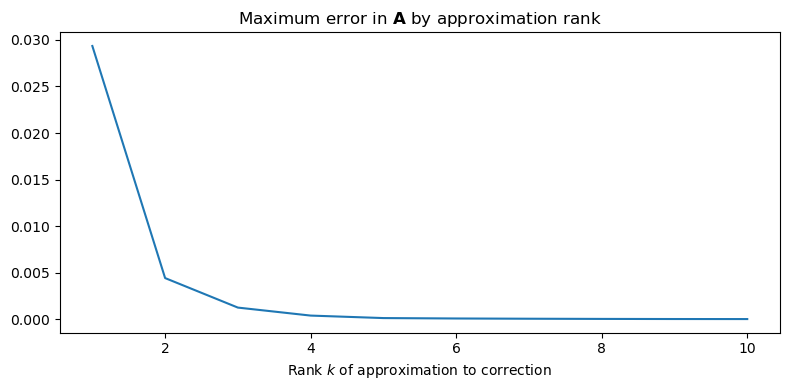

In [24]:
errs = np.empty(10)
for rk in range(1, 11):
    errs[rk-1] = np.max(np.abs(E_A - U[:, :rk] @ np.diag(s[:rk]) @ Vh[:rk, :]))
plt.figure(figsize=(8, 4))
plt.plot(range(1, 11), errs)
plt.xlabel('Rank $k$ of approximation to correction')
plt.title(r'Maximum error in $\mathbf{A}$ by approximation rank')
plt.tight_layout()
plt.savefig('figures/lecture10a_fig10.pdf', transparent=True)

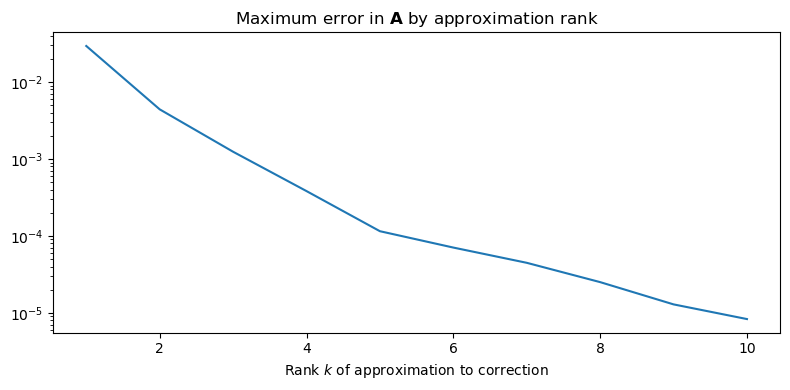

In [26]:
# same thing with a log 10 plot
plt.figure(figsize=(8, 4))
plt.semilogy(range(1, 11), errs)
plt.xlabel('Rank $k$ of approximation to correction')
plt.title(r'Maximum error in $\mathbf{A}$ by approximation rank')
plt.tight_layout()
plt.savefig('figures/lecture10a_fig11.pdf', transparent=True)